In [27]:
#Import libararies

In [140]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")

In [141]:
#Load Dataset(define df)

In [142]:
# Load dataset
df = pd.read_csv(r"C:\Users\ASHISH\Downloads\DATA Analyst\Black Friday Data.csv")

# Check data
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [143]:
#Initial Data Understanding (EDA Basics)

In [144]:
df.head()        # View first 5 rows
df.shape         # Rows and columns
df.columns       # Column names
df.info()        # Data types
df.describe()    # Statistical summary

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     550068 non-null  int64  
 1   Product_ID                  550068 non-null  object 
 2   Gender                      550068 non-null  object 
 3   Age                         550068 non-null  object 
 4   Occupation                  550068 non-null  int64  
 5   City_Category               550068 non-null  object 
 6   Stay_In_Current_City_Years  550068 non-null  object 
 7   Marital_Status              550068 non-null  int64  
 8   Product_Category_1          550068 non-null  int64  
 9   Product_Category_2          376430 non-null  float64
 10  Product_Category_3          166821 non-null  float64
 11  Purchase                    550068 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 50.4+ MB


,User_ID,Occupation,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
count,5.500680e+05,550068.000000,550068.000000,550068.000000,376430.000000,166821.000000,550068.000000
mean,1.003029e+06,8.076707,0.409653,5.404270,9.842329,12.668243,9263.968713
std,1.727592e+03,6.522660,0.491770,3.936211,5.086590,4.125338,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,2.000000,3.000000,12.000000
25%,1.001516e+06,2.000000,0.000000,1.000000,5.000000,9.000000,5823.000000
50%,1.003077e+06,7.000000,0.000000,5.000000,9.000000,14.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,15.000000,16.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,18.000000,18.000000,23961.000000


In [145]:
df.isnull().sum()

User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            173638
Product_Category_3            383247
Purchase                           0
dtype: int64

In [146]:
# Handling Missing Values

In [147]:
df['Product_Category_2'] = df['Product_Category_2'].fillna(0)
df['Product_Category_3'] = df['Product_Category_3'].fillna(0)

In [148]:
#Fix Stay_In_Current_City_Years Column

In [149]:
df['Stay_In_Current_City_Years'] = (
    df['Stay_In_Current_City_Years']
    .astype(str)
    .str.replace('+', '', regex=False)
    .astype(int)
)

In [150]:
#Remove duplicates

In [151]:
df.duplicated().sum()

np.int64(0)

In [152]:
#Remove Duplicates

In [153]:
df.drop_duplicates(inplace=True)

In [154]:
#Final Cleaning Validation

In [155]:
print("Missing Values After Cleaning:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

Missing Values After Cleaning:
User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category_1            0
Product_Category_2            0
Product_Category_3            0
Purchase                      0
dtype: int64

Data Types:
User_ID                         int64
Product_ID                     object
Gender                         object
Age                            object
Occupation                      int64
City_Category                  object
Stay_In_Current_City_Years      int64
Marital_Status                  int64
Product_Category_1              int64
Product_Category_2            float64
Product_Category_3            float64
Purchase                        int64
dtype: object


In [156]:
#City Loyalty Index

In [157]:
df['City_Loyalty_Index'] = df['Purchase'] * df['Stay_In_Current_City_Years']

In [158]:
#Customer Lifetime Value (CLV)

In [159]:
clv = df.groupby('User_ID')['Purchase'].sum().reset_index()
clv.rename(columns={'Purchase': 'Customer_Lifetime_Value'}, inplace=True)

In [160]:
#Average Purchase per Customer

In [161]:
avg_purchase = df.groupby('User_ID')['Purchase'].mean().reset_index()
avg_purchase.rename(columns={'Purchase': 'Avg_Purchase'}, inplace=True)

In [162]:
#Category Breadth (Product Variety)

In [163]:
category_breadth = df.groupby('User_ID')['Product_Category_1'].nunique().reset_index()
category_breadth.rename(columns={'Product_Category_1': 'Category_Breadth'}, inplace=True)

In [164]:
#Purchase Distribution (Histogram)

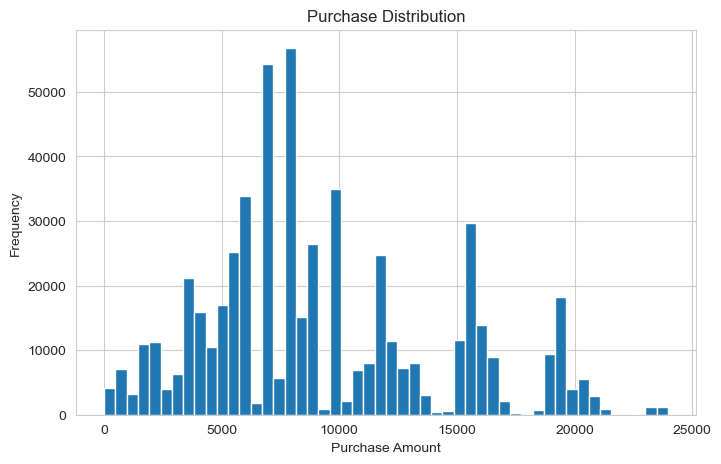

In [165]:
plt.figure(figsize=(8,5))
plt.hist(df['Purchase'], bins=50)
plt.title("Purchase Distribution")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")
plt.show()

In [166]:
#Gender vs Purchase (Spending Analysis)

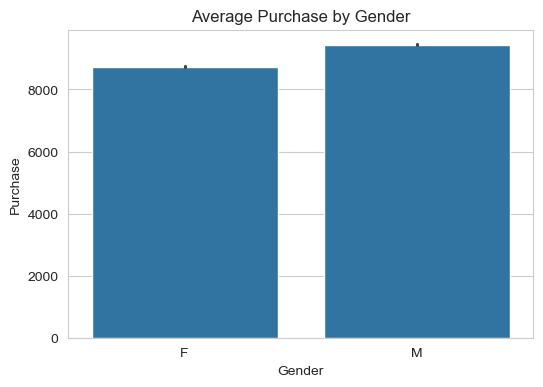

In [167]:
plt.figure(figsize=(6,4))
sns.barplot(x='Gender', y='Purchase', data=df)
plt.title("Average Purchase by Gender")
plt.show()

In [168]:
#Age Group vs Purchase

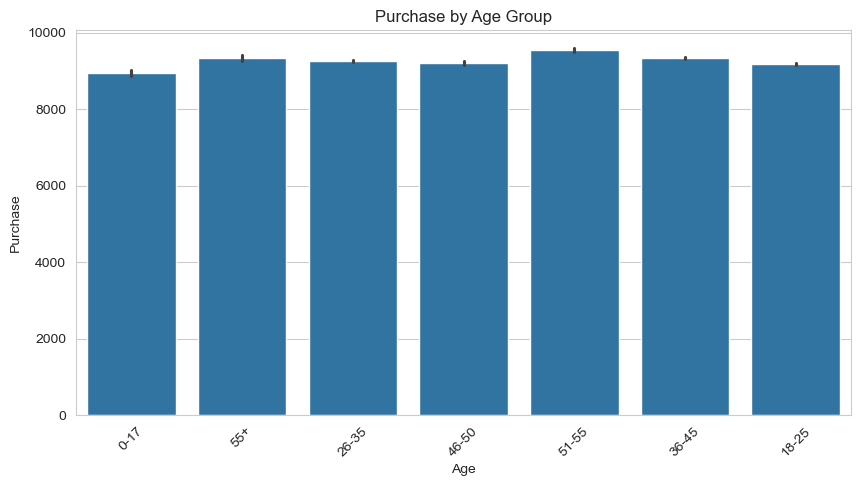

In [169]:
plt.figure(figsize=(10,5))
sns.barplot(x='Age', y='Purchase', data=df)
plt.title("Purchase by Age Group")
plt.xticks(rotation=45)
plt.show()

In [170]:
#City Category vs Sales

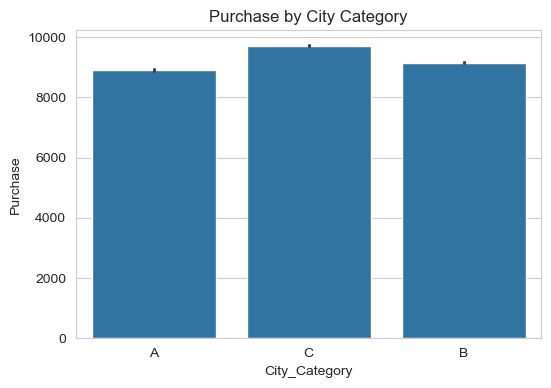

In [171]:
plt.figure(figsize=(6,4))
sns.barplot(x='City_Category', y='Purchase', data=df)
plt.title("Purchase by City Category")
plt.show()

In [172]:
#Marital Status vs Purchase

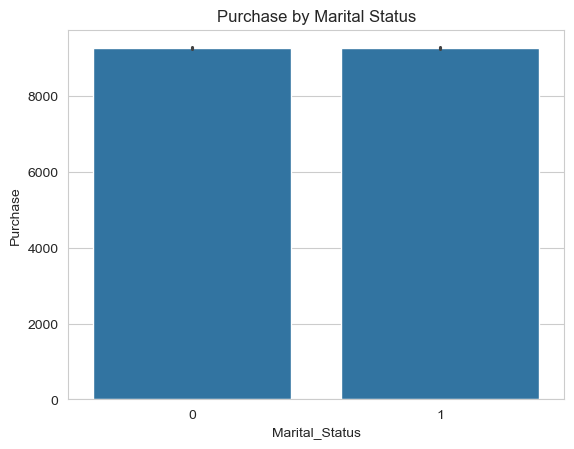

In [173]:
sns.barplot(x='Marital_Status', y='Purchase', data=df)
plt.title("Purchase by Marital Status")
plt.show()

In [174]:
#Top Product Categories Analysis

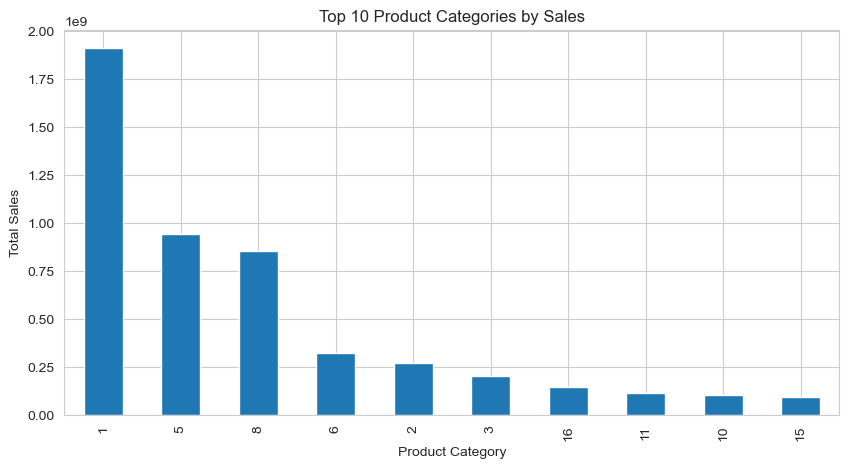

In [175]:
top_cat = df.groupby('Product_Category_1')['Purchase'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
top_cat.head(10).plot(kind='bar')
plt.title("Top 10 Product Categories by Sales")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.show()

In [176]:
#Correlation Heatmap (Advanced EDA)

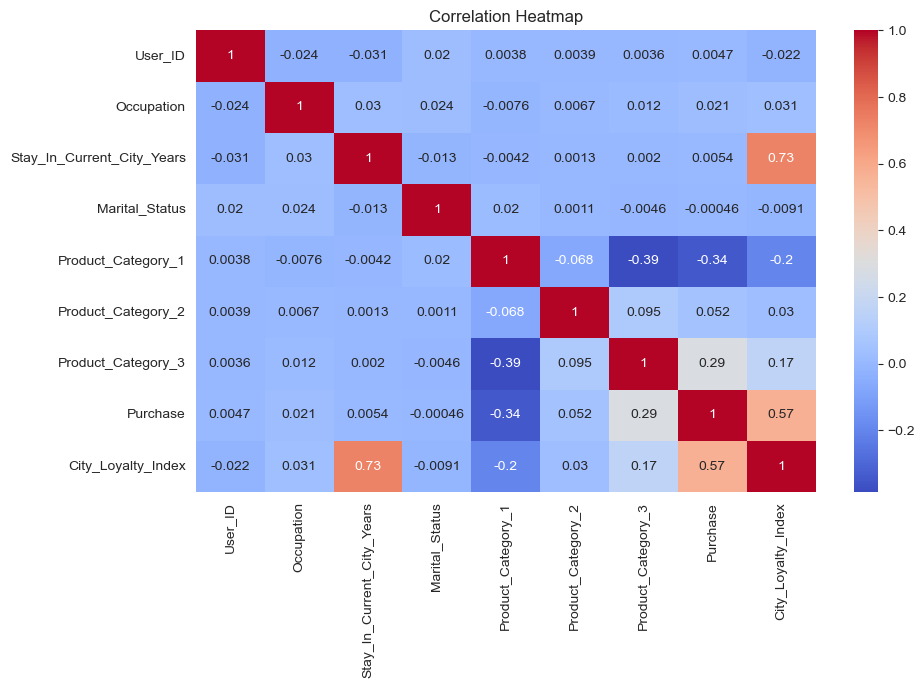

In [177]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [178]:
##Statistical Analysis (Very Important for Capstone)

In [179]:
#T-Test: Male vs Female Spending

In [180]:
male_purchase = df[df['Gender'] == 'M']['Purchase']
female_purchase = df[df['Gender'] == 'F']['Purchase']

t_stat, p_value = stats.ttest_ind(male_purchase, female_purchase)

print("T-Test Result")
print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Test Result
T-Statistic: 44.837957934353966
P-Value: 0.0


In [181]:
#ANOVA Test: Age Group vs Purchase

In [182]:
age_groups = [group['Purchase'].values for name, group in df.groupby('Age')]

f_stat, p_value = stats.f_oneway(*age_groups)

print("ANOVA Test Result")
print("F-Statistic:", f_stat)
print("P-Value:", p_value)

ANOVA Test Result
F-Statistic: 40.575799094504085
P-Value: 1.053563939251671e-49


In [183]:
#Correlation Analysis

In [184]:
correlation = df[['Occupation', 'Purchase', 'City_Loyalty_Index']].corr()
print(correlation)

                    Occupation  Purchase  City_Loyalty_Index
Occupation            1.000000  0.020833            0.031416
Purchase              0.020833  1.000000            0.570062
City_Loyalty_Index    0.031416  0.570062            1.000000


In [185]:
#KPI Calculations (For Dashboard Use)

In [186]:
total_sales = df['Purchase'].sum()
avg_purchase = df['Purchase'].mean()
total_customers = df['User_ID'].nunique()
total_products = df['Product_ID'].nunique()

print("Total Sales:", total_sales)
print("Average Purchase:", avg_purchase)
print("Total Customers:", total_customers)
print("Total Products:", total_products)

Total Sales: 5095812742
Average Purchase: 9263.968712959126
Total Customers: 5891
Total Products: 3631


In [187]:
#Final Professional Summary Code

In [188]:
# Cleaning
df['Product_Category_2'] = df['Product_Category_2'].fillna(0)
df['Product_Category_3'] = df['Product_Category_3'].fillna(0)

df['Stay_In_Current_City_Years'] = (
    df['Stay_In_Current_City_Years']
    .astype(str)
    .str.replace('+','', regex=False)
    .astype(int)
)

df.drop_duplicates(inplace=True)

# Feature Engineering
df['City_Loyalty_Index'] = df['Purchase'] * df['Stay_In_Current_City_Years']

# Validation
print(df.shape)
print(df.isnull().sum())
print(df.describe())

(550068, 13)
User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category_1            0
Product_Category_2            0
Product_Category_3            0
Purchase                      0
City_Loyalty_Index            0
dtype: int64
            User_ID     Occupation  Stay_In_Current_City_Years  \
count  5.500680e+05  550068.000000               550068.000000   
mean   1.003029e+06       8.076707                    1.858418   
std    1.727592e+03       6.522660                    1.289443   
min    1.000001e+06       0.000000                    0.000000   
25%    1.001516e+06       2.000000                    1.000000   
50%    1.003077e+06       7.000000                    2.000000   
75%    1.004478e+06      14.000000                    3.000000   
max    1.006040e+06      20.00